<a href="https://colab.research.google.com/github/vigneshvicky0246/inlighn-tech/blob/main/Traffic_Sign_Recognition_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
meowmeowmeowmeowmeow_gtsrb_german_traffic_sign_path = kagglehub.dataset_download('meowmeowmeowmeowmeow/gtsrb-german-traffic-sign')

print('Data source import complete.')


Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Data source import complete.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os
import random
import pandas as pd
import numpy as np
import cv2

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, GlobalAveragePooling2D
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
IMG_SIZE = (32, 32)
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EPOCHS = 50

In [ ]:
train_df = pd.read_csv("/kaggle/input/gtsrb-german-traffic-sign/Train.csv")
test_df = pd.read_csv("/kaggle/input/gtsrb-german-traffic-sign/Test.csv")

train_imgs = "/kaggle/input/gtsrb-german-traffic-sign/Train"
test_imgs = "/kaggle/input/gtsrb-german-traffic-sign/Test"

In [ ]:
train_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [ ]:
test_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


In [ ]:
class_names = {
    0:"Speed Limit (20Km/hr)", 1:"Speed Limit (30Km/hr)",
    2:"Speed Limit (50Km/hr)", 3: "Speed Limit (60Km/hr)",
    4: "Speed Limit (70Km/hr)", 5: "Speed Limit (80Km/hr)",
    6: "End of Speed Limit (80Km/hr)", 7: "Speed Limit (100Km/hr)",
    8: "Speed Limit (120Km/hr)", 9: "No Passing",
    10: "No Passing for trucks over 3.5 tons", 11: "Right of way",
    12: "Priotity Road", 13: "Yeild right of way",
    14: "Stop", 15: "Prohibited for all vehicles",
    16: "Trucks and tractors over 3.5 tons prohibited", 17: "Entery prohibited",
    18: "Danger", 19: "Single curve left",
    20: "Single curve right", 21: "Double curve",
    22: "Rough road", 23: "Slippery road",
    24: "Road narrows", 25: "Construction side ahead",
    26: "Signal lights ahead", 27: "Pedestrian crosswalk ahead",
    28: "Children", 29: "Bicycle crossing",
    30: "Unexpected ice danger", 31: "Wild animal crossing",
    32: "End of restrection", 33: "Mandatory direction of travel right",
    34: "Mandatory direction of travel left", 35: "Mandatory direction of travel ahead",
    36: "Straight or right", 37: "Straight or left",
    38: "Keep right", 39: "Keep left",
    40: "Traffic circle", 41: "End of no passing zone cars",
    42: "End of no passing zone vehicle over 3.5 tons"
}

train_df["ClassName"] = train_df['ClassId'].map(class_names)
test_df["ClassName"] = test_df['ClassId'].map(class_names)

In [ ]:
train_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path,ClassName
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png,Single curve right
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png,Single curve right
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png,Single curve right
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png,Single curve right
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png,Single curve right


In [ ]:
test_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path,ClassName
0,53,54,6,5,48,49,16,Test/00000.png,Trucks and tractors over 3.5 tons prohibited
1,42,45,5,5,36,40,1,Test/00001.png,Speed Limit (30Km/hr)
2,48,52,6,6,43,47,38,Test/00002.png,Keep right
3,27,29,5,5,22,24,33,Test/00003.png,Mandatory direction of travel right
4,60,57,5,5,55,52,11,Test/00004.png,Right of way


In [ ]:
train_df['ClassName'].value_counts()

,count
ClassName,
Speed Limit (50Km/hr),2250
Speed Limit (30Km/hr),2220
Yeild right of way,2160
Priotity Road,2100
Keep right,2070
No Passing for trucks over 3.5 tons,2010
Speed Limit (70Km/hr),1980
Speed Limit (80Km/hr),1860
Construction side ahead,1500


In [ ]:
test_df['ClassName'].value_counts()

,count
ClassName,
Speed Limit (50Km/hr),750
Yeild right of way,720
Speed Limit (30Km/hr),720
Keep right,690
Priotity Road,690
Speed Limit (70Km/hr),660
No Passing for trucks over 3.5 tons,660
Speed Limit (80Km/hr),630
Construction side ahead,480


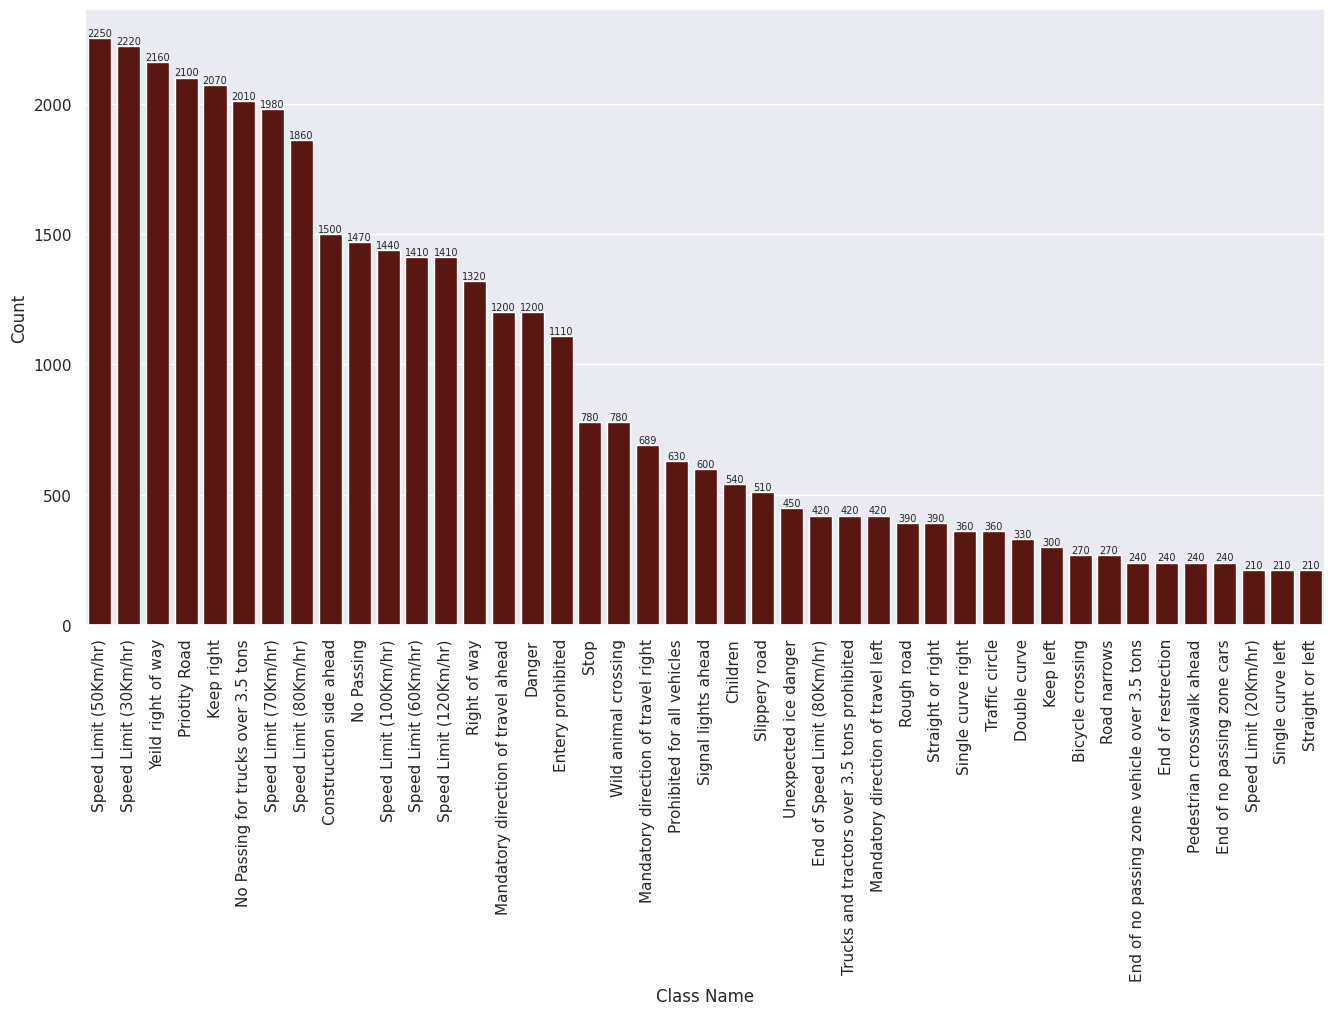

In [ ]:
plt.figure(figsize=(16, 8))
ax = sns.countplot(data=train_df, x="ClassName", order=train_df["ClassName"].value_counts().index, color="#660B05")
plt.xlabel("Class Name")
plt.ylabel("Count")
plt.xticks(rotation=90)
for container in ax.containers:
    ax.bar_label(container, fontsize=7)
plt.show()

In [ ]:
train_df["ClassId_str"] = train_df["ClassId"].astype(str)
train_df["ClassId"] = train_df["ClassId"].astype(int)
train_df["Path"] = train_df["Path"].str.replace("Train/", "")

train_data, valid_data = train_test_split(train_df, test_size=0.2, stratify=train_df['ClassId'], random_state=42)

In [ ]:
num_classes=len(train_df["ClassName"].unique())
num_classes

43

In [ ]:
train_data, valid_data = train_test_split(train_df, test_size=0.2, stratify=train_df['ClassId'], random_state=42)

In [ ]:
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=False,
    fill_mode='nearest'

)

train_gen_aug = train_datagen_aug.flow_from_dataframe(
    dataframe = train_data,
    directory=train_imgs,
    x_col = "Path",
    y_col = "ClassId_str",
    target_size = IMG_SIZE,
    class_mode="categorical",
    batch_size = BATCH_SIZE,
    shuffle = True
)

Found 31367 validated image filenames belonging to 43 classes.


In [ ]:
class_indices = train_gen_aug.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

In [ ]:
valid_datagen_aug = ImageDataGenerator(rescale=1./255)
test_datagen_aug = ImageDataGenerator(rescale=1./255)

valid_gen_aug = valid_datagen_aug.flow_from_dataframe(
    dataframe = valid_data,
    directory = train_imgs,
    x_col = "Path",
    y_col = "ClassId_str",
    target_size = IMG_SIZE,
    class_mode="categorical",
    batch_size = BATCH_SIZE,
    shuffle = False
)



test_df["ClassId_str"] = test_df["ClassId"].astype(str)
test_df["ClassId"] = test_df["ClassId"].astype(int)
test_df["Path"] = test_df["Path"].str.replace("Test/", "")

test_gen_aug = test_datagen_aug.flow_from_dataframe(
    dataframe = test_df,
    directory=test_imgs,
    x_col = "Path",
    y_col = "ClassId_str",
    target_size = IMG_SIZE,
    class_mode="categorical",
    batch_size = BATCH_SIZE,
    shuffle = False
)

Found 7842 validated image filenames belonging to 43 classes.
Found 12630 validated image filenames belonging to 43 classes.


In [ ]:
class_weight = compute_class_weight('balanced', classes=np.unique(train_df['ClassId']),
                                  y=train_df['ClassId'])
class_weights_dict = dict(enumerate(class_weight))
class_weights_dict

{0: np.float64(4.342081949058693),
 1: np.float64(0.41073748166771423),
 2: np.float64(0.4052609819121447),
 3: np.float64(0.6466930562427841),
 4: np.float64(0.46052384308198263),
 5: np.float64(0.49023505876469115),
 6: np.float64(2.1710409745293466),
 7: np.float64(0.6332202842377261),
 8: np.float64(0.6466930562427841),
 9: np.float64(0.620297421294099),
 10: np.float64(0.45365035288672917),
 11: np.float64(0.6907857646229739),
 12: np.float64(0.4342081949058693),
 13: np.float64(0.4221468561584841),
 14: np.float64(1.1690220632081096),
 15: np.float64(1.447360649686231),
 16: np.float64(2.1710409745293466),
 17: np.float64(0.8214749633354285),
 18: np.float64(0.7598643410852713),
 19: np.float64(4.342081949058693),
 20: np.float64(2.5328811369509046),
 21: np.float64(2.7631430584918957),
 22: np.float64(2.3380441264162193),
 23: np.float64(1.7879160966712266),
 24: np.float64(3.3771748492678726),
 25: np.float64(0.6078914728682171),
 26: np.float64(1.5197286821705427),
 27: np.flo

In [ ]:
train_gen_aug.class_indices == valid_gen_aug.class_indices

True

In [ ]:
model_aug = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding="same"),
    Conv2D(32, (3, 3), activation='relu', padding="same"),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu', padding="same"),
    Conv2D(64, (3, 3), activation='relu', padding="same"),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.2),

    Conv2D(128, (3, 3), activation='relu', padding="same"),
    Conv2D(256, (3, 3), activation='relu', padding="same"),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.2),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

In [ ]:
model_aug.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 474,443 (1.81 MB)

 Trainable params: 473,739 (1.81 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
model_aug.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='categorical_crossentropy',
             metrics = ['accuracy'])

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience = 8)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor = 'val_loss', patience = 2, verbose = 2, factor = 0.2,
                                              min_lr = 1e-5)

In [ ]:
history_aug=model_aug.fit(train_gen_aug, validation_data=valid_gen_aug, batch_size=BATCH_SIZE, epochs=EPOCHS,
                  callbacks=[early_stopping, reduce_lr], class_weight=class_weights_dict)

Epoch 1/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 370s 373ms/step - accuracy: 0.1316 - loss: 4.6124 - val_accuracy: 0.5250 - val_loss: 1.3853 - learning_rate: 0.0010
Epoch 2/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 312s 318ms/step - accuracy: 0.5406 - loss: 1.5422 - val_accuracy: 0.8412 - val_loss: 0.4762 - learning_rate: 0.0010
Epoch 3/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 310s 316ms/step - accuracy: 0.7491 - loss: 0.7401 - val_accuracy: 0.9212 - val_loss: 0.2467 - learning_rate: 0.0010
Epoch 4/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 314s 320ms/step - accuracy: 0.8418 - loss: 0.4678 - val_accuracy: 0.9503 - val_loss: 0.1572 - learning_rate: 0.0010
Epoch 5/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 314s 320ms/step - accuracy: 0.8848 - loss: 0.3429 - val_accuracy: 0.9630 - val_loss: 0.1203 - learning_rate: 0.0010
Epoch 6/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 313s 319ms/step - accuracy: 0.9107 - loss: 0.2637 - val_accuracy: 0.9471 - val_loss: 0.1803 - learning_rate: 0.0010
Epoch 7/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy

In [ ]:
test_loss, test_accuracy = model_aug.evaluate(test_gen_aug)
print(f"Test accuracy : {test_accuracy*100:.2f}%")
print(f"Test loss : {test_loss:.3f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 92s 233ms/step - accuracy: 0.9819 - loss: 0.0694
Test accuracy : 98.29%
Test loss : 0.068


In [ ]:
valid_loss, valid_accuracy = model_aug.evaluate(valid_gen_aug)
print(f"Validation accuracy : {valid_accuracy*100:.2f}%")
print(f"Validation loss : {valid_loss:.3f}")

246/246 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.9962 - loss: 0.0090
Validation accuracy : 99.62%
Validation loss : 0.012


In [ ]:
idx_to_class = {v: k for k, v in train_gen_aug.class_indices.items()}
true_labels = test_gen_aug.classes
pred_probs = model_aug.predict(test_gen_aug)
pred_labels = np.argmax(pred_probs, axis=1)
target_names = list(test_gen_aug.class_indices.keys())
print(classification_report(true_labels, pred_labels, target_names=target_names))

395/395 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        60
           1       0.98      0.99      0.99       720
          10       1.00      1.00      1.00       660
          11       0.95      0.97      0.96       420
          12       0.98      0.98      0.98       690
          13       0.99      1.00      1.00       720
          14       0.99      1.00      0.99       270
          15       1.00      1.00      1.00       210
          16       1.00      1.00      1.00       150
          17       1.00      0.91      0.95       360
          18       1.00      0.96      0.98       390
          19       1.00      1.00      1.00        60
           2       0.99      0.98      0.99       750
          20       0.98      1.00      0.99        90
          21       0.94      0.93      0.94        90
          22       1.00      0.97      0.98       120
          23       0.96      1.00     

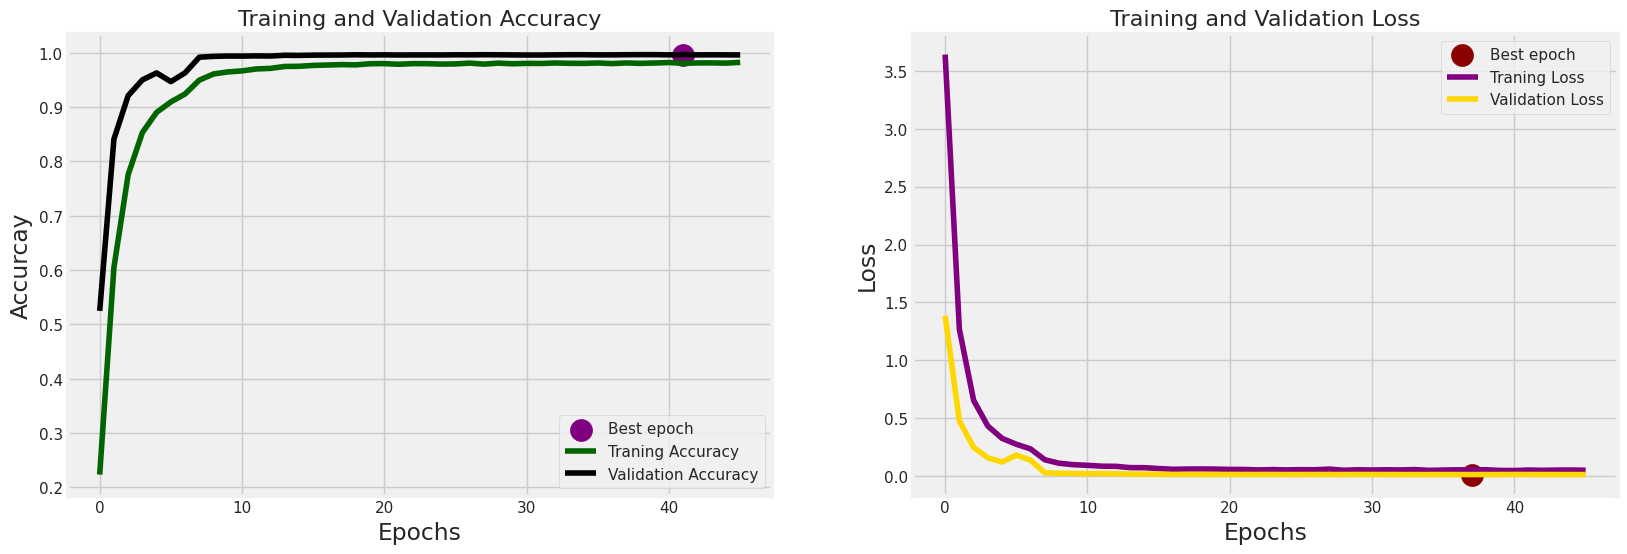

In [ ]:
#train history
train_acc = history_aug.history['accuracy']
train_loss = history_aug.history['loss']

#validatioin history
val_acc = history_aug.history['val_accuracy']
val_loss = history_aug.history['val_loss']

min_loss = np.argmin(val_loss) # get min val loss epoch #
val_lowest = val_loss[min_loss]

max_acc = np.argmax(val_acc) #get max val acc epoch #
val_max = val_acc[max_acc]

epochs_ = [i for i in range(len(train_acc))]

#Plot Style
plt.figure(figsize = (20,6))
plt.style.use('fivethirtyeight')

#Plot Accuracy
plt.subplot(1, 2, 1)
plt.scatter(max_acc, val_max, s = 250, c = "purple", label = "Best epoch")
plt.plot(epochs_, train_acc, 'darkgreen', label = "Traning Accuracy")
plt.plot(epochs_, val_acc, 'black', label = "Validation Accuracy")

plt.title("Training and Validation Accuracy", fontsize = 16)
plt.xlabel("Epochs")
plt.ylabel("Accurcay")
plt.legend()

#Plot Loss
plt.subplot(1, 2, 2)
plt.scatter(min_loss, val_lowest, s = 250, c = "darkred", label = "Best epoch")
plt.plot(epochs_, train_loss, 'purple', label = "Traning Loss")
plt.plot(epochs_, val_loss, 'gold', label = "Validation Loss")

plt.title("Training and Validation Loss", fontsize = 16)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

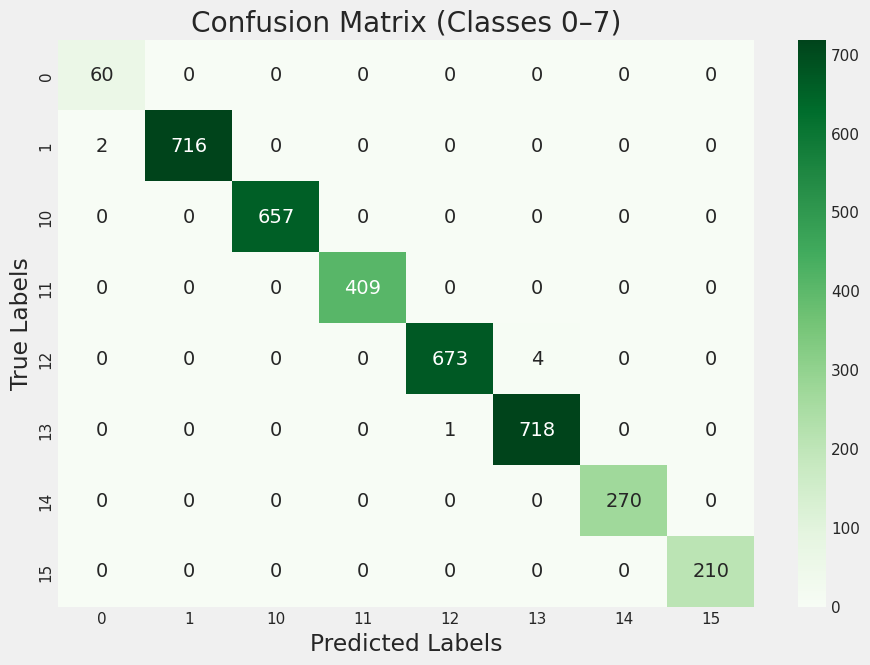

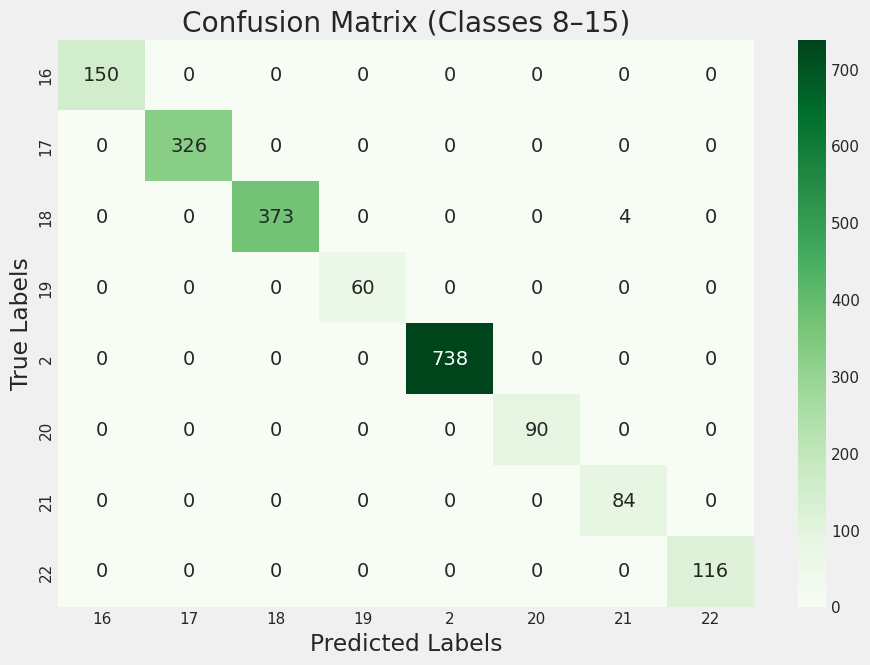

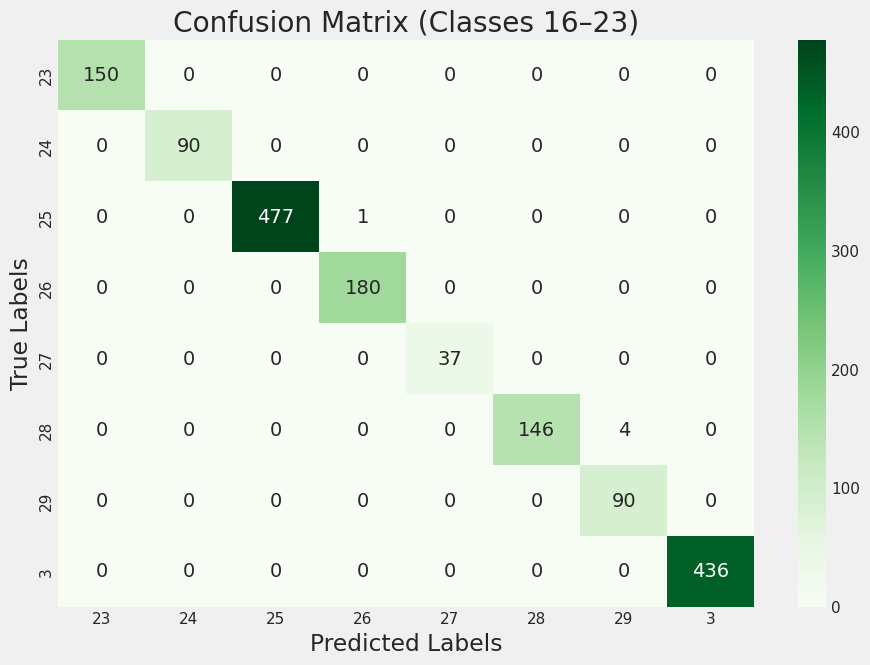

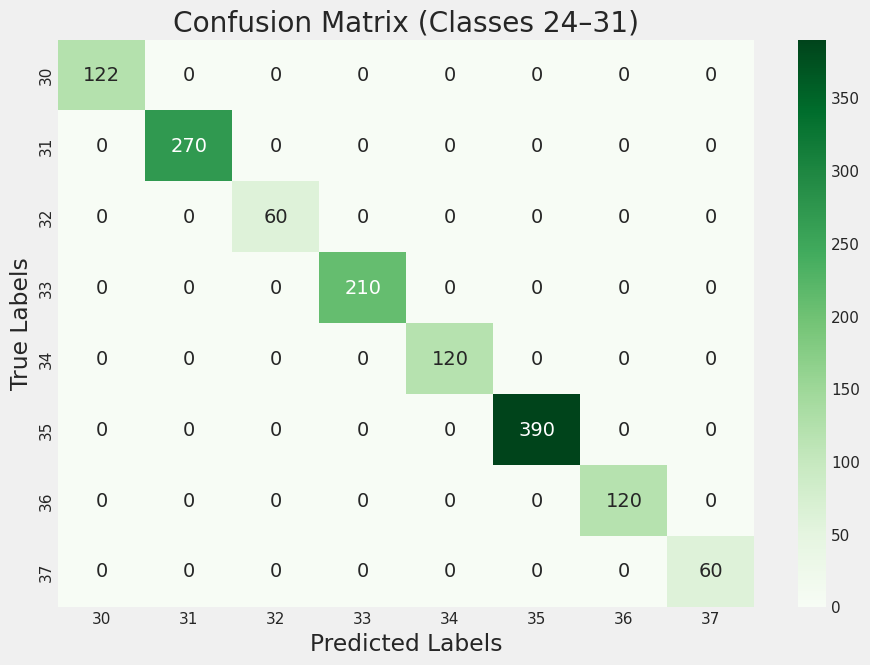

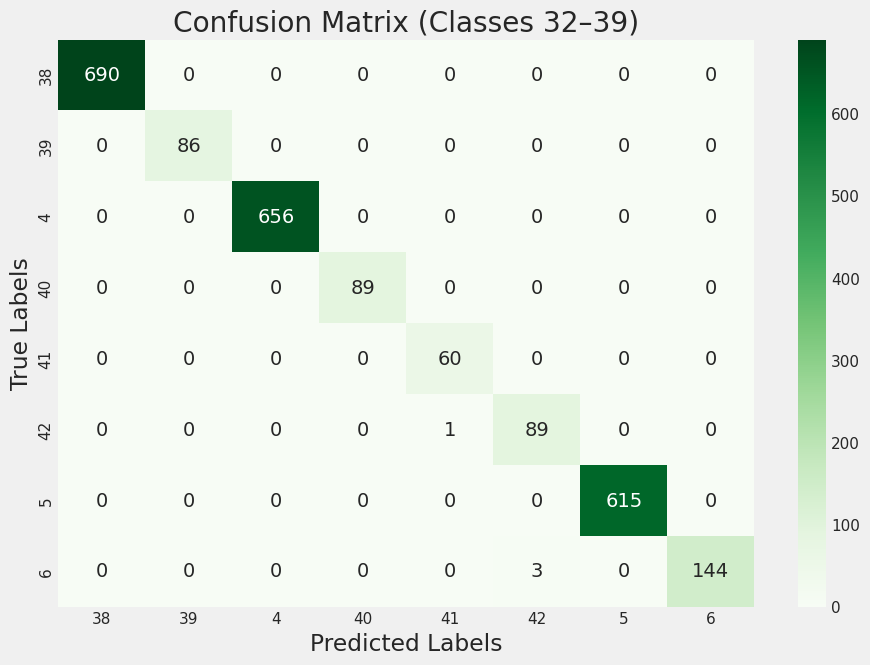

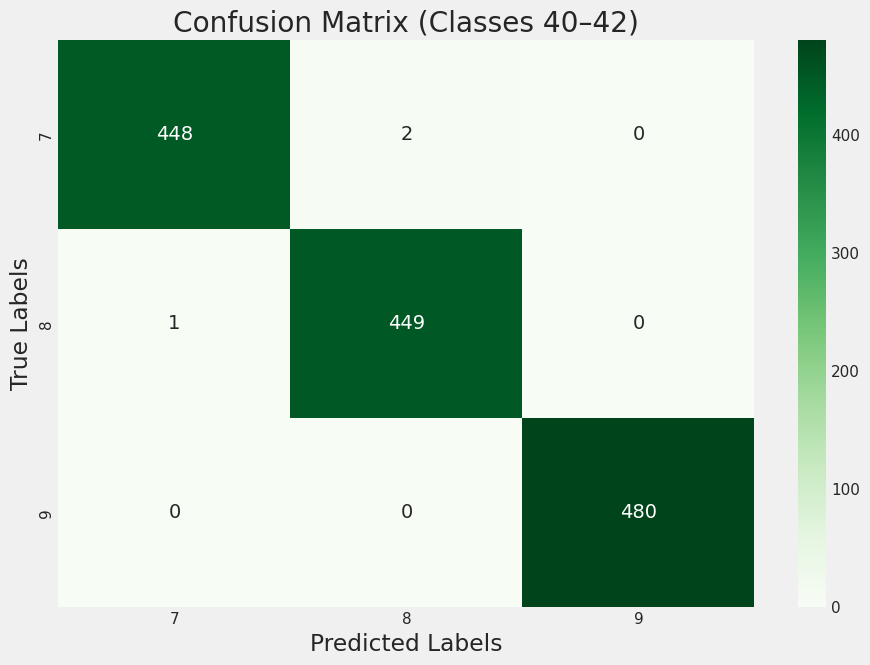

In [ ]:
cm = confusion_matrix(true_labels, pred_labels)
class_names = list(test_gen_aug.class_indices.keys())
chunk_size = 8
for start in range(0, len(class_names), chunk_size):
    end = min(start + chunk_size, len(class_names))
    cm_sliced = cm[start:end, start:end]
    labels_sliced = class_names[start:end]

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_sliced, annot=True, cmap='Greens', fmt="d",
                xticklabels=labels_sliced, yticklabels=labels_sliced)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"Confusion Matrix (Classes {start}–{end-1})")
    plt.show()

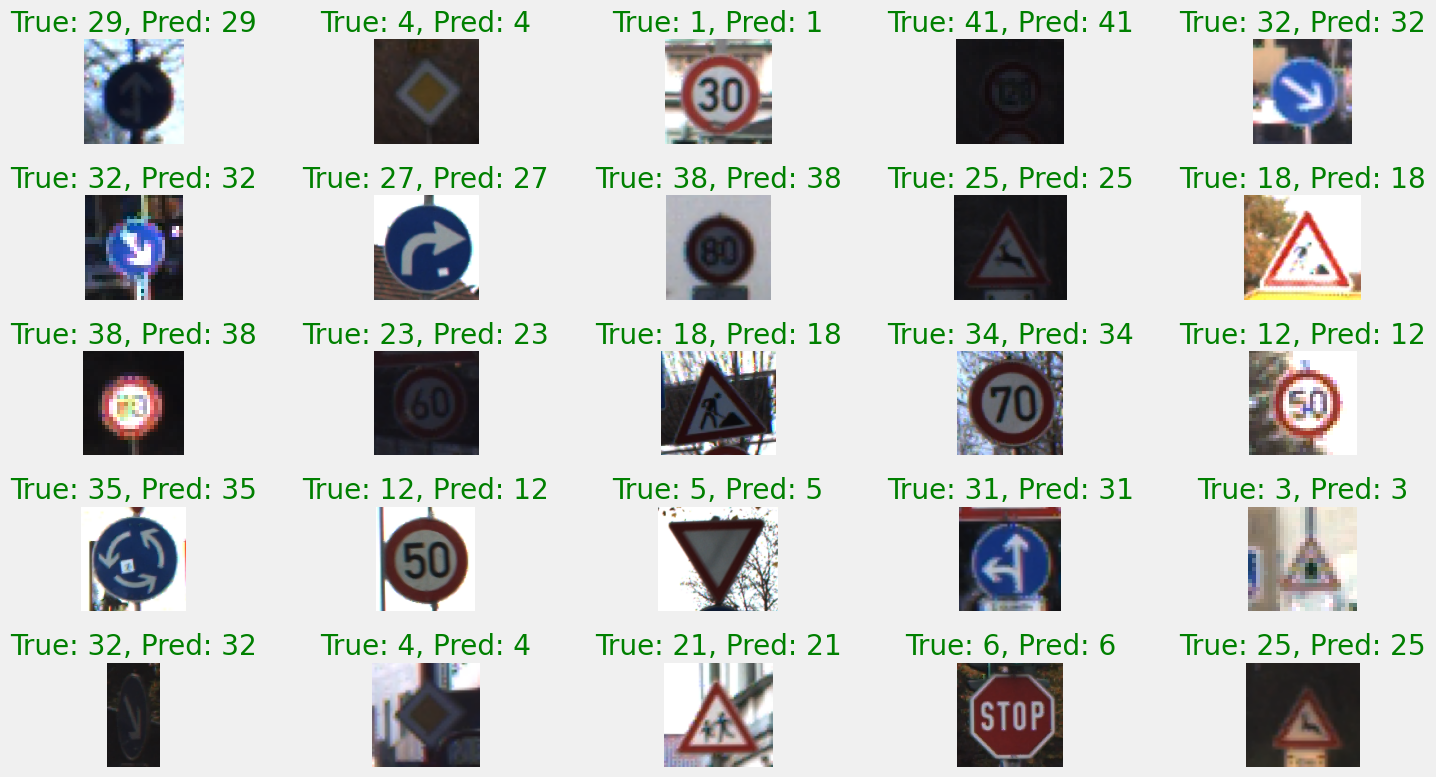

In [ ]:
file_paths = test_gen_aug.filepaths
num_imgs = 25
indices = random.sample(range(len(file_paths)), num_imgs)

plt.figure(figsize=(16, 8))

for i, idx in enumerate(indices):
    img_path = file_paths[idx]
    img = plt.imread(img_path)

    true_label = true_labels[idx]
    pred_label = pred_labels[idx]
    color = "green" if true_label == pred_label else "red"
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}, Pred: {pred_label}", color=color)
    plt.axis("off")


plt.tight_layout()
plt.show()